## Introduction

Notebook for calculating the value of the $R^{*}$ metric as defined in https://mc-stan.org/posterior/reference/rstar.html. The TLDR is that R* is a measure of the ability of a machine learning classifier to distinguish between Markov Chains. The metric is defined as $\bar{a}*N$ where $\bar{a}$ is the accuracy of an algorithm and $N$ is the number of input Markov Chains.

We interpret an $R^{*}\approx1$ as being good since the chain cannot distinguish between chains. As $R^{*}\rightarrow N$ the metric can tell apart more chains!

To account for the inherent variance of ML methods we calculate $R^{*}$ multiple times and present it as mean $(R^{* })$ ± standard deviation. We also include the confusion matrix. This a grid of "true/false" positive rates which is effectively a proxy for $R^{*}$ with more diagonal matrices corresponding to algorithms being better able to tell apart fits.

In [1]:
from pathlib import Path
from MaCh3PythonUtils.diagnostics.rstar import RStar
from MaCh3PythonUtils.file_handling.chain_handler import MultiChainHandler


Using cpu device

In [2]:
# # Set up the console for rich output
# from rich.console import Console
# console = Console()
# console.is_jupyter = False # Disable Jupyter mode for rich output

## File Handling

First things first we need to do file handling. The commented out cell below can download a demonstration chain for testing purposes

In [3]:
# # Optional code to download demo files, commented out since it's not needed
# import gdown

# # Download file from google drive

# file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"

# # download the file
# input_file = Path("../models/demo_chain.root")

# if not input_file.exists():
#     # download the file
#     input_file.parent.mkdir(parents=True, exist_ok=True)
#     gdown.download(file_url, str(input_file), quiet=False, fuzzy=True)


Next we need to actually grab files in the demonstration we use the same file twice, commented out in the below cells is an example of using file paths to get files instead

In [4]:
# Manually specify the file paths for the demonstration
# FILE_LIST = [
#      "../models/demo_chain.root",
#      "../models/demo_chain.root"
# ]

In [5]:
# Get file paths automatically/through wild cards
import uproot
from rich import print as rprint


FOLDERS = ["/home/henryi/scratch"]

# Define the file name pattern to search for, default is "*.root"
file_name_pattern = "*trimmed*.root"

# Automatically get .root files containing "posteriors" key
FILE_LIST = []

for folder in FOLDERS:
    if not Path(folder).exists():
        rprint(f"[red]Folder {folder} does not exist. Skipping...")
        continue
    # Check if folder contains files matching the pattern
    if not any(Path(folder).glob(file_name_pattern)):
        rprint(f"[red]No files matching pattern '{file_name_pattern}' found in {folder}. Skipping...")
        continue
    # Create a list of file paths that match the pattern and contain "posteriors" key
    for file in Path(folder).glob(file_name_pattern):
        try:
            with uproot.open(file) as f:
                if any(key.startswith("posteriors") for key in f.keys()):
                    FILE_LIST.append(str(file))
        except Exception as e:
            rprint(f"[red]Error opening file {file}: {e}")
    
FILE_LIST = [
    str(file)
    for folder in FOLDERS
    for file in Path(folder).glob(file_name_pattern)
    if any(key.startswith("posteriors") for key in uproot.open(file).keys())
]

rprint(f"[green]Using: {FILE_LIST}")

Using: 
['/home/henryi/scratch/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root
', 
'/home/henryi/scratch/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root'
, 
'/home/henryi/scratch/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root'
]

Now we shove the files into the `chain_handler`. This is a wrapper around uproot file opening

In [6]:
# Setup files
chain_handler = MultiChainHandler(FILE_LIST, "posteriors", False, True)
chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov"])
chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<12345678", "step>10000"])
chain_handler.convert_ttree_to_array()

Attempting to open /home/henryi/scratch/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root
Succesfully opened /home/henryi/scratch/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root:posteriors
Attempting to open /home/henryi/scratch/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root
Succesfully opened /home/henryi/scratch/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root:posteriors
Attempting to open /home/henryi/scratch/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root
Succesfully opened /home/henryi/scratch/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root:posteriors


Converting TTrees:   0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Setting up the Machine Learning
The next step here is to set up the ML; there are a few things we need to do.

1. Set the `INTERFACE` variable. This can be either `scikit` or `xgboost`.
2. Set the `ALGORITHM` variable. For:
    * `xgboost` use `xgbclassifier` or `xgdrfclassifier`
    * `scikit` use `histboostclassifier`

    > **Note:**  
    > You can find the full list of algorithms in the [ML_Factory source code](../src/MaCh3PythonUtils/machine_learning/ml_factory.py#23), in `__IMPLEMENTED_ALGORITHMS`
3. Set the model kwargs. These are the allowed key words when making the model!. For:
    * xgboost classifiers use the [scikit estimator interface](https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html)
    * scikit classifiers use the scikit documentation for each algorithm. the recommended algorithm is [HistGradientBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)
4. Set the number of algorithms you want to train. Since R* is inherently random it is good to calculate it from an ensemble of algorithms. More is better but  ~100 provides a good estimate

In [ ]:
# F
INTERFACE = "xgboost"
ALGORITHM = "xgbclassifier"

MODEL_KWARGS = {
    "learning_rate": 0.07,
    "n_estimators": 10,
    # "early_stopping_rounds": 20,
    "verbose": 0,
    "n_jobs": 8,
}

#numbers of fitters i.e. number of trees in the ensemble
N_FITTERS = 50

We're now ready to run R*! The code will do the following

1. Create N_FITTERS models and set their training/testing sets
2. Train each fitter (this will take time!)
3. Calculate R* from training

Creating 5 models using xgbclassifier algorithm

Creating Models:   0%|          | 0/5 [00:00<?, ?it/s]

Creating 5 different train/test splits...

Assigning data to 5 models in parallel...

Assigning Data:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training Models:   0%|          | 0/5 [00:00<?, ?it/s]

LogLoss for each model:


Trained 5 models

Running R* diagnostics for train data...

Getting R* for train:   0%|          | 0/5 [00:00<?, ?it/s]

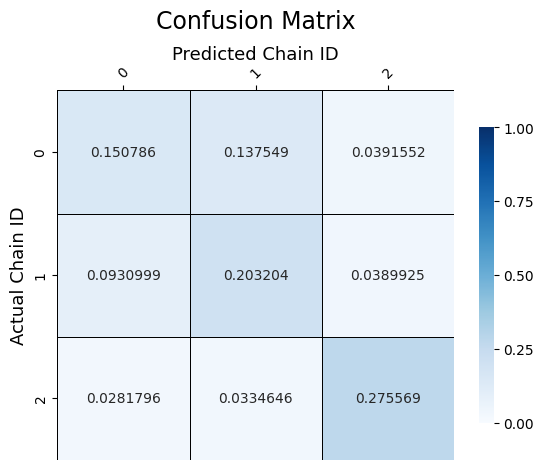

<Figure size 640x480 with 0 Axes>

Average R* for train data: 1.8887±0.0091

 For 3 files, an R* of ~1.0 indicates a model that cannot distinguish between chains (i.e. they're similarly 
mixed).
                As R*->3 the model becomes better at telling the difference between chains!

Running R* diagnostics for test data...

Getting R* for test:   0%|          | 0/5 [00:00<?, ?it/s]

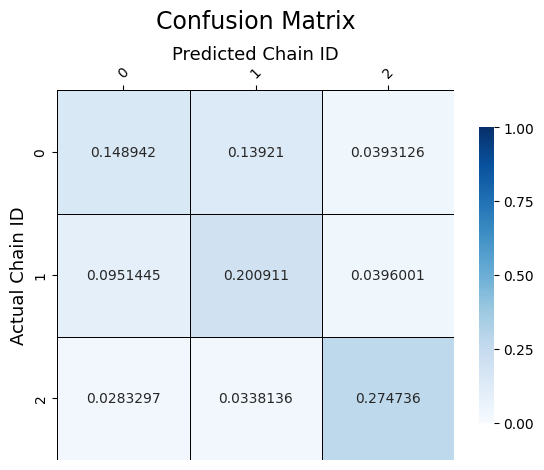

<Figure size 640x480 with 0 Axes>

Average R* for test data: 1.8738±0.0076

 For 3 files, an R* of ~1.0 indicates a model that cannot distinguish between chains (i.e. they're similarly 
mixed).
                As R*->3 the model becomes better at telling the difference between chains!

train_rstar_histogram.pdf


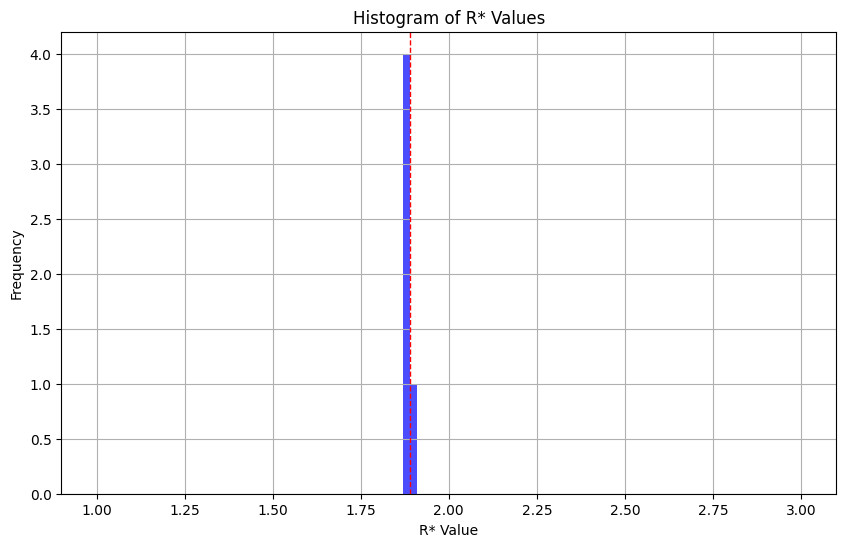

Saved histogram to train_rstar_histogram.pdf

test_rstar_histogram.pdf


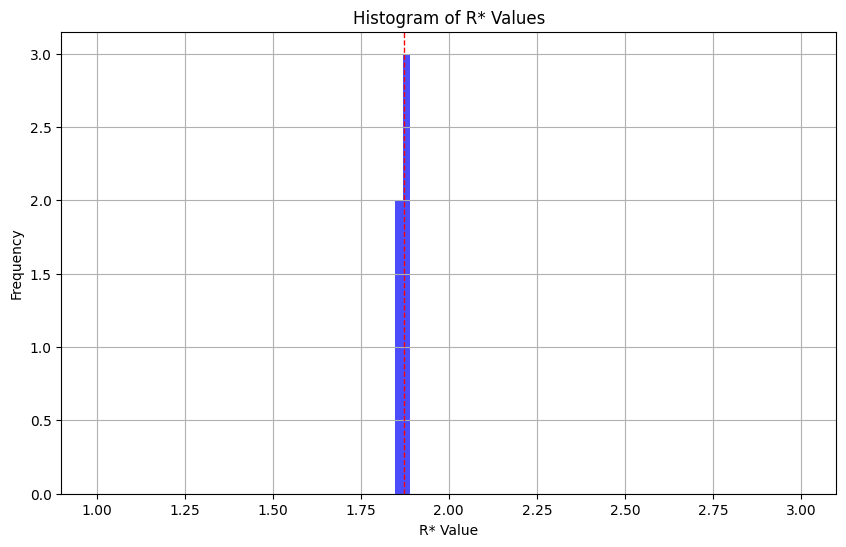

Saved histogram to test_rstar_histogram.pdf

In [ ]:
# Do RStar for two identical files
rstar = RStar(chain_handler, n_fitters=N_FITTERS, algorithm=ALGORITHM, interface=INTERFACE, **MODEL_KWARGS)
rstar_vals = rstar.get_rstar()
rstar.make_rstar_hist(rstar_vals['train_rstar'], "train_rstar_histogram.pdf")
rstar.make_rstar_hist(rstar_vals['test_rstar'], "test_rstar_histogram.pdf")


# Code for testing

Below is some code for testing, if this is still here when you're viewing this I've messed something up!

In [ ]:
# # Setup files
# NOISE = 1e-5


# # Now we want to modify the second file slightly
# file_2_view = chain_handler.ttree_array[chain_handler.ttree_array["chain_id"]==1]
# means = np.mean(file_2_view, axis=0)
# random_noise = np.random.uniform(-NOISE, NOISE, size=file_2_view.shape)
# # Add random noise to the second file
# # Only apply noise to the columns except 'chain_id'
# cols_to_modify = [col for col in file_2_view.columns if col != "chain_id"]

# # Broadcast means for selected columns
# means_arr = means[cols_to_modify].values
# random_noise_mod = random_noise[:, :len(cols_to_modify)] * means_arr

# # Update the DataFrame in place
# chain_handler.ttree_array.loc[chain_handler.ttree_array["chain_id"]==1, cols_to_modify] += random_noise_mod

In [ ]:
# # Do RStar for noisy data
# rstar = RStar(chain_handler, n_fitters=N_FITTERS, algorithm="xgbclassifier", interface="xgboost", **MODEL_KWARGS)
# rstar_vals = rstar.get_rstar()
# rstar.make_rstar_hist(rstar_vals['train_rstar'], "train_rstar_histogram.pdf")
# rstar.make_rstar_hist(rstar_vals['test_rstar'], "test_rstar_histogram.pdf")